In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train = pd.read_csv(r"C:\Users\nidhin\Downloads\train_ctrUa4K.csv")
test = pd.read_csv(r"C:\Users\nidhin\Downloads\test_lAUu6dG.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (614, 13)
Test shape: (367, 12)


In [3]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
train.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [6]:
train.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
train["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [8]:
train["Loan_Status"].value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

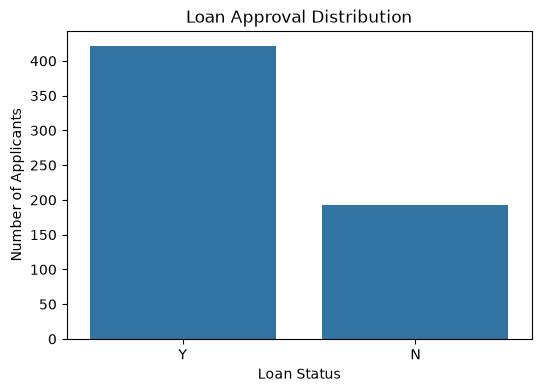

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(data=train, x="Loan_Status")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

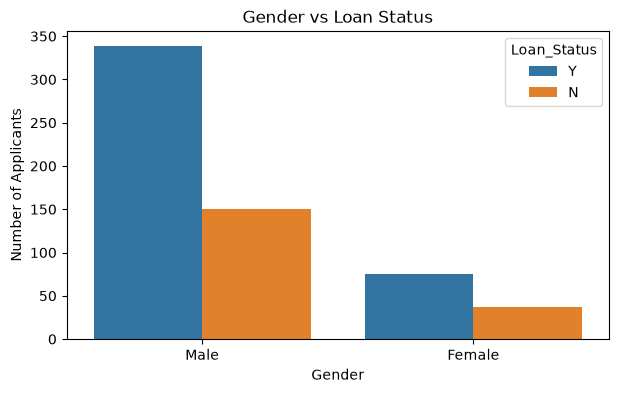

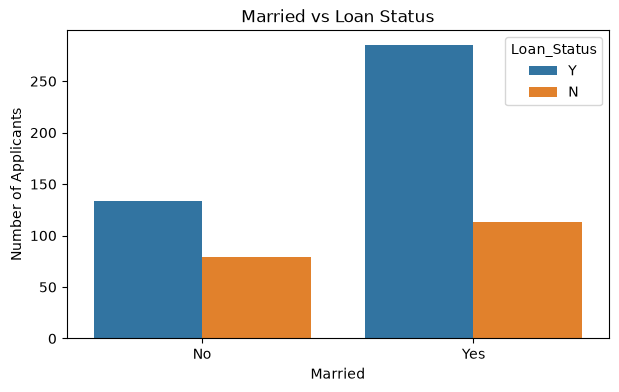

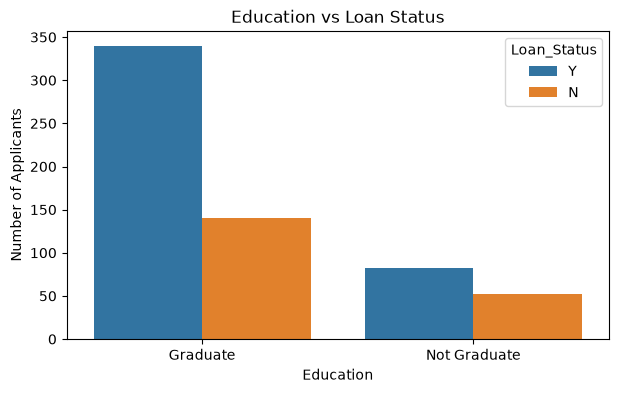

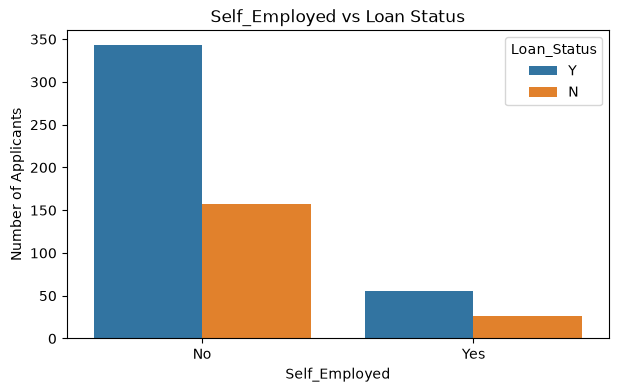

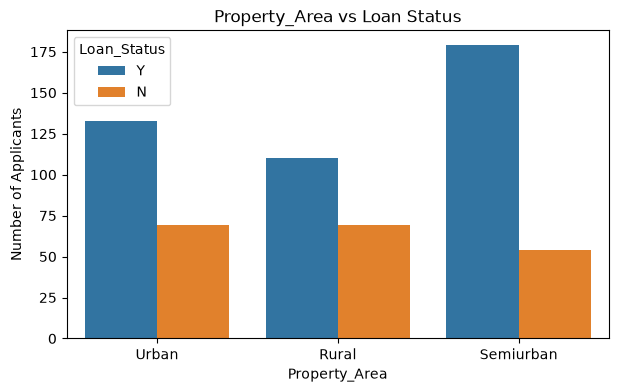

In [13]:
categorical_columns = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area"
]

for column in categorical_columns:
    plt.figure(figsize=(7, 4))
    
    sns.countplot(
        data=train,
        x=column,
        hue="Loan_Status"
    )
    
    plt.title(f"{column} vs Loan Status")
    plt.xlabel(column)
    plt.ylabel("Number of Applicants")
    
    plt.show()

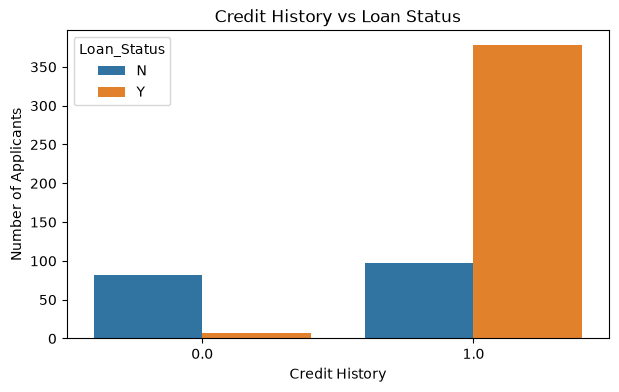

In [14]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=train,
    x="Credit_History",
    hue="Loan_Status"
)

plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")

plt.show()

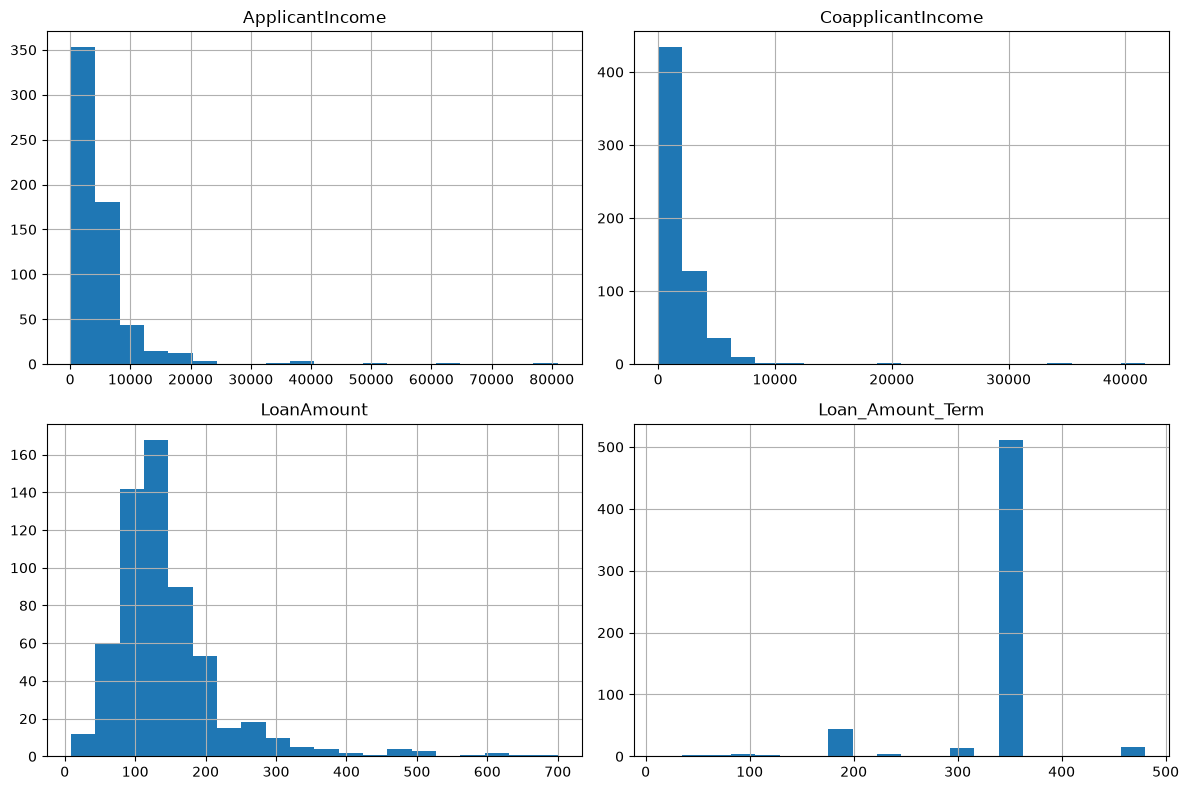

In [15]:
numerical_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

train[numerical_columns].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

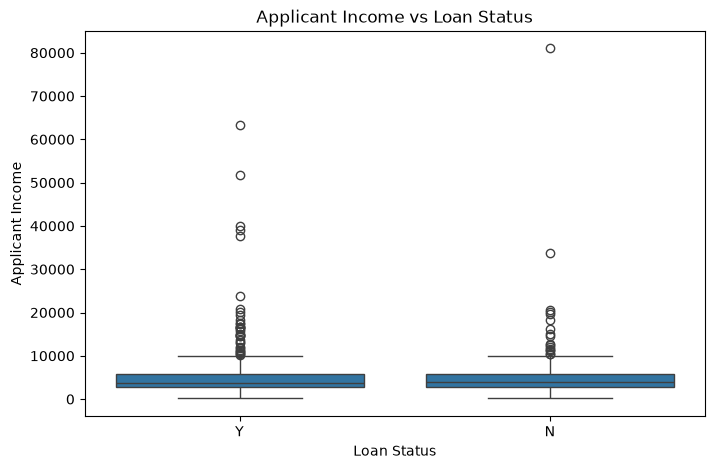

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="Loan_Status",
    y="ApplicantIncome"
)

plt.title("Applicant Income vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")

plt.show()

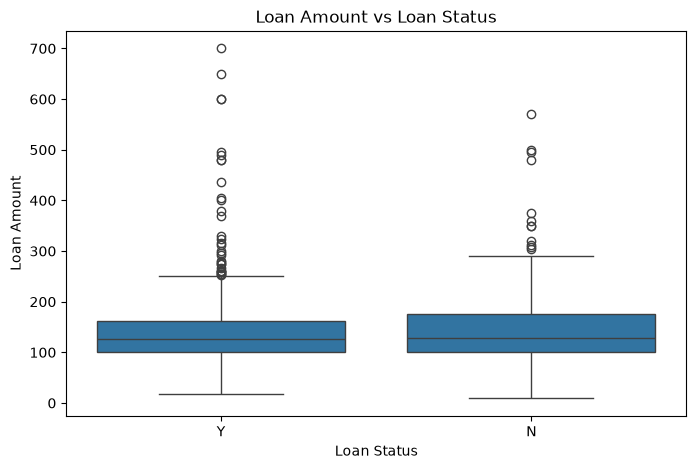

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="Loan_Status",
    y="LoanAmount"
)

plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")

plt.show()

In [18]:
X = train.drop(columns=["Loan_ID", "Loan_Status"])
y = train["Loan_Status"]

test_ids = test["Loan_ID"]
X_test = test.drop(columns=["Loan_ID"])

In [19]:
categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area"
]

numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

print("Training data:", X_train.shape)
print("Validation data:", X_valid.shape)

Training data: (491, 11)
Validation data: (123, 11)


In [21]:
print("Training data:", X_train.shape)
print("Validation data:", X_valid.shape)

Training data: (491, 11)
Validation data: (123, 11)


In [27]:
X_train_num = X_train[numerical_features]
X_valid_num = X_valid[numerical_features]
X_test_num = X_test[numerical_features]

X_train_cat = X_train[categorical_features]
X_valid_cat = X_valid[categorical_features]
X_test_cat = X_test[categorical_features]

In [28]:
from sklearn.impute import SimpleImputer

In [29]:
num_imputer = SimpleImputer(strategy="median")

In [30]:
X_train_num = num_imputer.fit_transform(X_train_num)
X_valid_num = num_imputer.transform(X_valid_num)
X_test_num = num_imputer.transform(X_test_num)

In [31]:
cat_imputer = SimpleImputer(strategy="most_frequent")

In [32]:
X_train_cat = cat_imputer.fit_transform(X_train_cat)
X_valid_cat = cat_imputer.transform(X_valid_cat)
X_test_cat = cat_imputer.transform(X_test_cat)

In [33]:
X_train_num = pd.DataFrame(
    X_train_num,
    columns=numerical_features,
    index=X_train.index
)

X_valid_num = pd.DataFrame(
    X_valid_num,
    columns=numerical_features,
    index=X_valid.index
)

X_test_num = pd.DataFrame(
    X_test_num,
    columns=numerical_features,
    index=X_test.index
)

In [34]:
X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=categorical_features,
    index=X_train.index
)

X_valid_cat = pd.DataFrame(
    X_valid_cat,
    columns=categorical_features,
    index=X_valid.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=categorical_features,
    index=X_test.index
)

In [35]:
X_train_cat = pd.get_dummies(X_train_cat)
X_valid_cat = pd.get_dummies(X_valid_cat)
X_test_cat = pd.get_dummies(X_test_cat)

In [36]:
X_valid_cat = X_valid_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

X_test_cat = X_test_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

In [37]:
X_train_processed = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_valid_processed = pd.concat(
    [X_valid_num, X_valid_cat],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

In [38]:
print("Training:", X_train_processed.shape)
print("Validation:", X_valid_processed.shape)
print("Test:", X_test_processed.shape)

Training: (491, 21)
Validation: (123, 21)
Test: (367, 21)


In [39]:
X_train_processed.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,...,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Credit_History_0.0,Credit_History_1.0,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
154,3254.0,0.0,50.0,360.0,False,True,True,False,True,False,...,False,True,False,True,False,False,True,False,False,True
239,3315.0,0.0,96.0,360.0,False,True,False,True,False,True,...,False,True,False,True,False,False,True,False,True,False
448,3340.0,1710.0,150.0,360.0,False,True,False,True,False,False,...,False,True,False,True,False,True,False,True,False,False
471,2653.0,1500.0,113.0,180.0,False,True,False,True,False,True,...,False,False,True,True,False,True,False,True,False,False
273,2620.0,2223.0,150.0,360.0,False,True,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_num)
X_valid_num = scaler.transform(X_valid_num)
X_test_num = scaler.transform(X_test_num)

In [44]:
X_train_num = pd.DataFrame(
    X_train_num,
    columns=numerical_features,
    index=X_train.index
)

X_valid_num = pd.DataFrame(
    X_valid_num,
    columns=numerical_features,
    index=X_valid.index
)

X_test_num = pd.DataFrame(
    X_test_num,
    columns=numerical_features,
    index=X_test.index
)

In [45]:
X_train_processed = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_valid_processed = pd.concat(
    [X_valid_num, X_valid_cat],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [47]:
logistic_model = LogisticRegression()

In [48]:
logistic_model.fit(X_train_processed, y_train)

LogisticRegression()

In [49]:
y_pred_logistic = logistic_model.predict(X_valid_processed)

In [50]:
logistic_accuracy = accuracy_score(y_valid, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.8617886178861789


 Model 1: Logistic Regression

Validation Accuracy: 86.18%

In [51]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
decision_tree_model = DecisionTreeClassifier(random_state=42)

In [53]:
decision_tree_model.fit(X_train_processed, y_train)

DecisionTreeClassifier(random_state=42)

In [54]:
y_pred_tree = decision_tree_model.predict(X_valid_processed)

In [55]:
tree_accuracy = accuracy_score(y_valid, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.7398373983739838


### Model 2: Decision Tree

Validation Accuracy: 73.98%

In [56]:
tree_train_pred = decision_tree_model.predict(X_train_processed)

tree_train_accuracy = accuracy_score(y_train, tree_train_pred)

print("Decision Tree Training Accuracy:", tree_train_accuracy)

Decision Tree Training Accuracy: 1.0


In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
random_forest_model = RandomForestClassifier(random_state=42)

In [59]:
random_forest_model.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

In [60]:
y_pred_rf = random_forest_model.predict(X_valid_processed)

In [61]:
rf_accuracy = accuracy_score(y_valid, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8130081300813008


### Model 3: Random Forest
Validation Accuracy: 81.30%

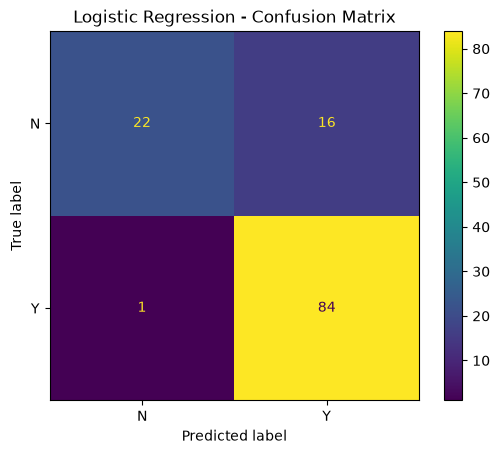

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_valid, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["N", "Y"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [101]:
X = train.drop(columns=["Loan_ID", "Loan_Status"])
y = train["Loan_Status"]

X_test = test.drop(columns=["Loan_ID"])

In [102]:
numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

In [103]:
X_num = X[numerical_features]
X_test_num = X_test[numerical_features]

In [104]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

In [105]:
X_num = num_imputer.fit_transform(X_num)
X_test_num = num_imputer.transform(X_test_num)

In [106]:
categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area"
]

In [107]:
X_cat = X[categorical_features]
X_test_cat = X_test[categorical_features]

In [108]:
cat_imputer = SimpleImputer(strategy="most_frequent")

In [109]:
X_cat = cat_imputer.fit_transform(X_cat)
X_test_cat = cat_imputer.transform(X_test_cat)

In [110]:
X_cat = pd.DataFrame(
    X_cat,
    columns=categorical_features
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=categorical_features
)

In [121]:
X_cat = pd.get_dummies(X_cat, dtype= 'int')
X_test_cat = pd.get_dummies(X_test_cat, dtype= 'int')

In [122]:
X_test_cat = X_test_cat.reindex(
    columns=X_cat.columns,
    fill_value=0
)

In [123]:
X_num = pd.DataFrame(
    X_num,
    columns=numerical_features
)

X_test_num = pd.DataFrame(
    X_test_num,
    columns=numerical_features
)

In [124]:
X_processed = pd.concat(
    [X_num, X_cat],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

In [125]:
print("Training data:", X_processed.shape)
print("Test data:", X_test_processed.shape)

Training data: (614, 21)
Test data: (367, 21)


In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [126]:
X_num_scaled = scaler.fit_transform(X_num)
X_test_num_scaled = scaler.transform(X_test_num)

In [127]:
X_num_scaled = pd.DataFrame(
    X_num_scaled,
    columns=numerical_features
)

X_test_num_scaled = pd.DataFrame(
    X_test_num_scaled,
    columns=numerical_features
)

In [128]:
X_processed = pd.concat(
    [X_num_scaled, X_cat],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_num_scaled, X_test_cat],
    axis=1
)

In [129]:
print("Training data:", X_processed.shape)
print("Test data:", X_test_processed.shape)

Training data: (614, 21)
Test data: (367, 21)


In [130]:
X_processed.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,...,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Credit_History_0.0,Credit_History_1.0,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0.072991,-0.554487,-0.211241,0.273231,0,1,1,0,1,0,...,0,1,0,1,0,0,1,0,0,1
1,-0.134412,-0.038732,-0.211241,0.273231,0,1,0,1,0,1,...,0,1,0,1,0,0,1,1,0,0
2,-0.393747,-0.554487,-0.948996,0.273231,0,1,0,1,1,0,...,0,1,0,0,1,0,1,0,0,1
3,-0.462062,0.251980,-0.306435,0.273231,0,1,0,1,1,0,...,0,0,1,1,0,0,1,0,0,1
4,0.097728,-0.554487,-0.056551,0.273231,0,1,1,0,1,0,...,0,1,0,1,0,0,1,0,0,1


In [131]:
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression()

final_model.fit(X_processed, y)

LogisticRegression()

In [132]:
test_predictions = final_model.predict(X_test_processed)

In [133]:
pd.Series(test_predictions).value_counts()

Y    306
N     61
Name: count, dtype: int64

In [134]:
submission = pd.DataFrame({
    "Loan_ID": test["Loan_ID"],
    "Loan_Status": test_predictions
})

submission.head()

,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y


In [138]:
submission.to_csv("loan_prediction_submission.csv", index=False)

In [139]:
pd.read_csv("loan_prediction_submission.csv").head()

,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y
